# Tag Quality Experiments

Three questions:

1. **Language tag source** — are language tags coming from the LLM suggest step or the tech-stack step?
2. **Dedup threshold calibration** — at what similarity score do pairs stop being true duplicates?
3. **Singleton quality** — are the 7k+ singleton tags genuinely niche or LLM noise?

In [1]:
import sqlite3
import struct
import json
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

DB_PATH = Path('../govtech.db')
assert DB_PATH.exists(), f'DB not found at {DB_PATH.resolve()}'
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

def q(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params or [])

def unpack_embedding(data):
    """Deserialise embedding stored as packed float32 bytes."""
    if data is None:
        return None
    n = len(data) // 4
    return np.array(struct.unpack(f'{n}f', data), dtype=np.float32)

def normalise(M):
    """L2-normalise rows of a matrix."""
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    return M / np.clip(norms, 1e-10, None)

print('Connected. DB size:', DB_PATH.stat().st_size // (1024*1024), 'MB')

Connected. DB size: 236 MB


---
## Experiment 1: Language Tag Source

Tags are saved with `source = 'llm'` or `'tech-stack'`. If language tags are mostly `tech-stack`, it's a one-line pipeline fix. If they're `llm`, we need a prompt change or post-filter.

In [2]:
LANGUAGE_TAGS = [
    'javascript', 'python', 'java', 'typescript', 'html', 'css', 'php',
    'ruby', 'shell', 'r', 'scala', 'c#', 'kotlin', 'go', 'rust', 'c',
    'c++', 'perl', 'swift', 'matlab', 'bash', 'json', 'xml', 'yaml',
    'sql', 'makefile',
]

ph = ','.join(['?'] * len(LANGUAGE_TAGS))
df_lang_src = q(
    f"""SELECT tag, source, COUNT(DISTINCT html_url) as repos
        FROM repository_tags
        WHERE tag IN ({ph})
        GROUP BY tag, source
        ORDER BY tag, source""",
    LANGUAGE_TAGS
)

pivot = df_lang_src.pivot_table(index='tag', columns='source', values='repos', fill_value=0)
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False)

print('Language tags by source (repos):')
print(pivot.to_string())
print()
total_llm = int(pivot.get('llm', pd.Series([0])).sum())
total_ts  = int(pivot.get('tech-stack', pd.Series([0])).sum())
total = total_llm + total_ts
print(f'LLM:        {total_llm:,} ({total_llm/total*100:.1f}%)')
print(f'tech-stack: {total_ts:,} ({total_ts/total*100:.1f}%)')

Language tags by source (repos):
source       llm  tech-stack   total
tag                                 
javascript  69.0      7669.0  7738.0
python      53.0      7563.0  7616.0
html         2.0      3966.0  3968.0
java        79.0      3464.0  3543.0
typescript  42.0      2798.0  2840.0
shell        0.0      2172.0  2172.0
php         37.0      2011.0  2048.0
ruby        32.0      1948.0  1980.0
r            6.0      1742.0  1748.0
css          2.0      1647.0  1649.0
scala       11.0      1503.0  1514.0
c#           0.0      1358.0  1358.0
kotlin       6.0      1253.0  1259.0
go          15.0       894.0   909.0
c++          2.0       380.0   382.0
c            3.0       300.0   303.0
makefile     0.0       238.0   238.0
perl         2.0       188.0   190.0
swift        1.0       148.0   149.0
rust         2.0        91.0    93.0
matlab       0.0        62.0    62.0
xml         13.0        45.0    58.0
yaml         2.0        51.0    53.0
sql          3.0        45.0    48.0
json 

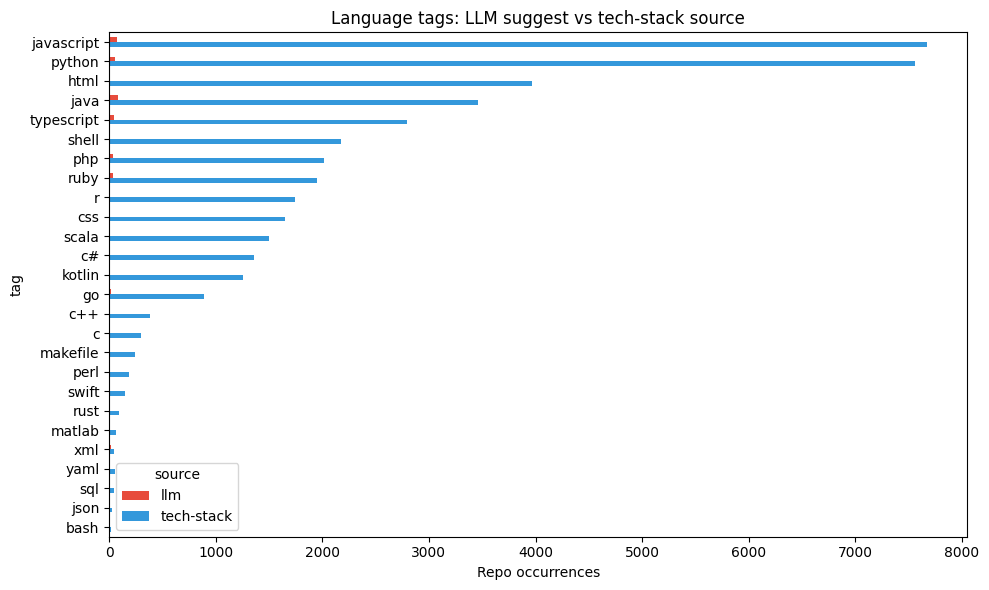

Saved lang_tag_source.png


In [3]:
cols = [c for c in ['llm', 'tech-stack'] if c in pivot.columns]
fig, ax = plt.subplots(figsize=(10, 6))
pivot[cols].plot(kind='barh', ax=ax, color=['#e74c3c', '#3498db'])
ax.set_title('Language tags: LLM suggest vs tech-stack source')
ax.set_xlabel('Repo occurrences')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('lang_tag_source.png', dpi=120)
plt.show()
print('Saved lang_tag_source.png')

**Conclusion 1:** Fill in after running.

---
## Experiment 2: Dedup Threshold Calibration

Current threshold: 0.85. Sample tag pairs at different similarity bands and inspect whether they're real duplicates.

In [4]:
# Load tags with embeddings
rows = conn.execute("""
    SELECT tag, embedding, usage_count
    FROM tags
    WHERE embedding IS NOT NULL AND merged_into IS NULL
    ORDER BY usage_count DESC
""").fetchall()

valid_tags, embeddings = [], []
for row in rows:
    emb = unpack_embedding(row['embedding'])
    if emb is not None:
        valid_tags.append(row['tag'])
        embeddings.append(emb)

E_all = np.stack(embeddings)
E_norm_all = normalise(E_all)
tag_to_idx = {t: i for i, t in enumerate(valid_tags)}

print(f'Tags with embeddings: {len(valid_tags):,}')
print(f'Embedding dimension:  {E_all.shape[1]}')

Tags with embeddings: 11,103
Embedding dimension:  1536


In [5]:
# Sample 500 tags, compute pairwise similarities
np.random.seed(42)
N = len(valid_tags)
sample_size = min(500, N)
idx = np.random.choice(N, sample_size, replace=False)
E_sample = E_norm_all[idx]
tags_sample = [valid_tags[i] for i in idx]

sims = E_sample @ E_sample.T

pairs = []
for i in range(sample_size):
    for j in range(i+1, sample_size):
        s = float(sims[i, j])
        if s >= 0.60:
            pairs.append((tags_sample[i], tags_sample[j], round(s, 4)))

df_pairs = pd.DataFrame(pairs, columns=['tag_a', 'tag_b', 'similarity'])
df_pairs = df_pairs.sort_values('similarity', ascending=False).reset_index(drop=True)

print(f'Pairs >= 0.60: {len(df_pairs):,}')
print()
bands = [(0.95, 1.0), (0.90, 0.95), (0.85, 0.90), (0.80, 0.85), (0.75, 0.80), (0.70, 0.75), (0.60, 0.70)]
print('Pairs per band:')
for lo, hi in bands:
    n = ((df_pairs['similarity'] >= lo) & (df_pairs['similarity'] < hi)).sum()
    print(f'  [{lo:.2f}, {hi:.2f}): {n:4d}')

Pairs >= 0.60: 217

Pairs per band:
  [0.95, 1.00):    0
  [0.90, 0.95):    0
  [0.85, 0.90):    0
  [0.80, 0.85):    6
  [0.75, 0.80):   11
  [0.70, 0.75):   25
  [0.60, 0.70):  175


In [6]:
# Sample pairs per band — the key human-review output
print('=== PAIRS BY SIMILARITY BAND (sample for review) ===\n')
for lo, hi in bands:
    mask = (df_pairs['similarity'] >= lo) & (df_pairs['similarity'] < hi)
    subset = df_pairs[mask].sample(min(12, mask.sum()), random_state=42) if mask.sum() > 0 else df_pairs[mask]
    print(f'--- [{lo:.2f}, {hi:.2f}) --- ({mask.sum()} total, showing {len(subset)})')
    for _, row in subset.iterrows():
        print(f'  {row["similarity"]:.3f}  {row["tag_a"]:35s}  {row["tag_b"]}')
    print()

=== PAIRS BY SIMILARITY BAND (sample for review) ===

--- [0.95, 1.00) --- (0 total, showing 0)

--- [0.90, 0.95) --- (0 total, showing 0)

--- [0.85, 0.90) --- (0 total, showing 0)

--- [0.80, 0.85) --- (6 total, showing 6)
  0.819  profiler                             profiling
  0.816  process-tracking                     service-tracking
  0.806  modular-application                  modular-framework
  0.811  uri-processing                       url-processing
  0.810  hpc-management                       hpc-configuration
  0.810  image-processing                     image-handling

--- [0.75, 0.80) --- (11 total, showing 11)
  0.783  api-adapter                          api-implementation
  0.798  acoustics                            bioacoustics
  0.753  hpc-library                          hpc-configuration
  0.751  maker-tool                           programming-tool
  0.791  microsoft-office                     microsoft
  0.794  error-modeling                       threat-m

In [7]:
# Check known near-duplicates we spotted manually
known_pairs = [
    ('a-b-testing', 'ab-testing'),
    ('antivirus', 'anti-virus'),
    ('angular', 'angularjs'),
    ('admin-tool', 'admin-tools'),
    ('accessibility-tool', 'accessibility-tools'),
    ('machine-learning', 'ml'),
    ('continuous-integration', 'ci'),
    ('open-data', 'public-data'),
    ('devops', 'dev-ops'),
]

print('Known near-duplicate pairs — actual similarity scores:')
print(f'{"pair":<70} {"sim":>6}  threshold')
print('-' * 90)
for t1, t2 in known_pairs:
    if t1 in tag_to_idx and t2 in tag_to_idx:
        i, j = tag_to_idx[t1], tag_to_idx[t2]
        sim = float(E_norm_all[i] @ E_norm_all[j])
        if sim >= 0.85:   verdict = 'caught at 0.85 ✓'
        elif sim >= 0.80: verdict = 'caught at 0.80'
        elif sim >= 0.75: verdict = 'caught at 0.75'
        else:             verdict = 'too far apart'
        print(f'  {t1} <-> {t2:<40} {sim:.3f}  {verdict}')
    else:
        missing = [t for t in [t1, t2] if t not in tag_to_idx]
        print(f'  {t1} <-> {t2:<40}   N/A  not in taxonomy: {missing}')

Known near-duplicate pairs — actual similarity scores:
pair                                                                      sim  threshold
------------------------------------------------------------------------------------------
  a-b-testing <-> ab-testing                               0.691  too far apart
  antivirus <-> anti-virus                               0.817  caught at 0.80
  angular <-> angularjs                                0.587  too far apart
  admin-tool <-> admin-tools                              0.843  caught at 0.80
  accessibility-tool <-> accessibility-tools                      0.940  caught at 0.85 ✓
  machine-learning <-> ml                                         N/A  not in taxonomy: ['ml']
  continuous-integration <-> ci                                         N/A  not in taxonomy: ['ci']
  open-data <-> public-data                              0.789  caught at 0.75
  devops <-> dev-ops                                  0.808  caught at 0.80


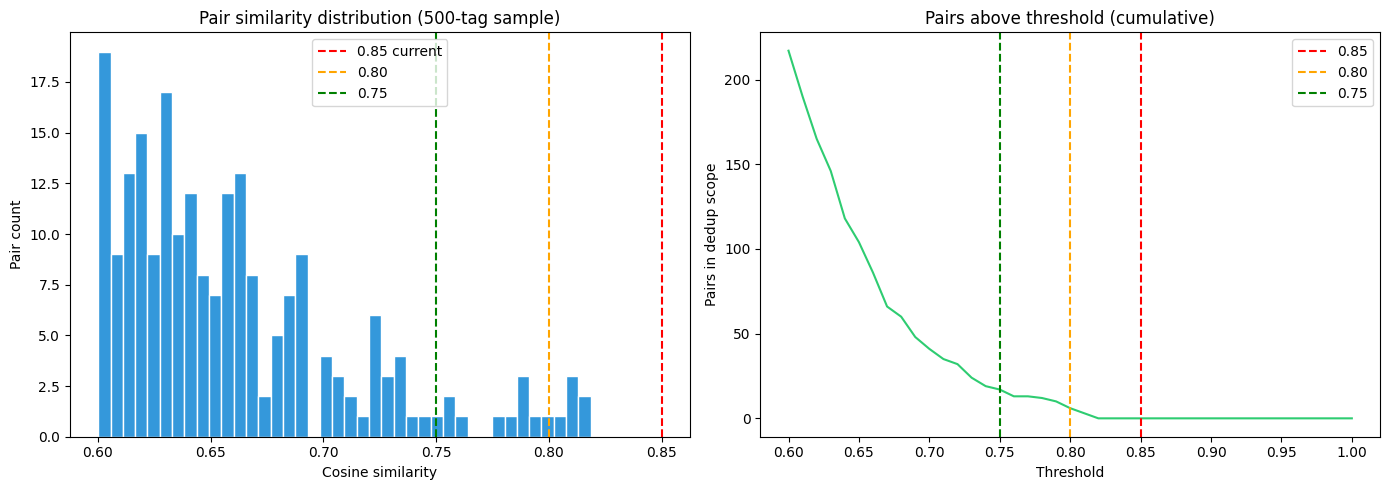

Saved dedup_threshold.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_pairs['similarity'], bins=40, color='#3498db', edgecolor='white')
for thresh, col, lbl in [(0.85,'red','0.85 current'), (0.80,'orange','0.80'), (0.75,'green','0.75')]:
    axes[0].axvline(thresh, color=col, linestyle='--', label=lbl)
axes[0].set_title('Pair similarity distribution (500-tag sample)')
axes[0].set_xlabel('Cosine similarity')
axes[0].set_ylabel('Pair count')
axes[0].legend()

thresholds = np.arange(0.60, 1.01, 0.01)
counts = [(df_pairs['similarity'] >= t).sum() for t in thresholds]
axes[1].plot(thresholds, counts, color='#2ecc71')
for thresh, col, lbl in [(0.85,'red','0.85'), (0.80,'orange','0.80'), (0.75,'green','0.75')]:
    axes[1].axvline(thresh, color=col, linestyle='--', label=lbl)
axes[1].set_title('Pairs above threshold (cumulative)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Pairs in dedup scope')
axes[1].legend()

plt.tight_layout()
plt.savefig('dedup_threshold.png', dpi=120)
plt.show()
print('Saved dedup_threshold.png')

**Conclusion 2:** Fill in after reviewing pairs above.

---
## Experiment 3: Singleton Tag Quality

7,712 tags appear in only one repo. How many are genuine vs noise vs missed dedup?

In [9]:
df_singletons = q("""
    SELECT rt.tag, rt.source, r.name, r.owner, r.country, r.language,
           r.description, r.stars
    FROM repository_tags rt
    JOIN repositories r ON rt.html_url = r.html_url
    WHERE rt.tag IN (
        SELECT tag FROM repository_tags
        GROUP BY tag HAVING COUNT(DISTINCT html_url) = 1
    )
    ORDER BY r.stars DESC
""")

print(f'Singleton tag instances: {len(df_singletons):,}')
print(f'Unique singleton tags:   {df_singletons["tag"].nunique():,}')
print()
print('Source breakdown:')
print(df_singletons.groupby('source')['tag'].count().to_string())

Singleton tag instances: 7,712
Unique singleton tags:   7,712

Source breakdown:
source
llm           6092
tech-stack    1620


In [10]:
# Pattern-based classification
singleton_tags = df_singletons['tag'].unique().tolist()

version_re = re.compile(r'v?\d+[._]\d+|[-_]\d{1,2}$|-\d{4}$')
framework_re = re.compile(r'angular|react|vue|django|rails|spring|laravel|symfony|flask|fastapi', re.I)

cats = {'version_specific': [], 'framework_specific': [], 'short_noise': [], 'complex': [], 'other': []}
for tag in singleton_tags:
    if len(tag) <= 3:
        cats['short_noise'].append(tag)
    elif version_re.search(tag):
        cats['version_specific'].append(tag)
    elif framework_re.search(tag):
        cats['framework_specific'].append(tag)
    elif tag.count('-') >= 3:
        cats['complex'].append(tag)
    else:
        cats['other'].append(tag)

print('Singleton tag categories:')
for cat, tags in cats.items():
    pct = len(tags) / len(singleton_tags) * 100
    print(f'  {cat:25s}: {len(tags):5,}  ({pct:.1f}%)')

print()
print('Version-specific examples:')
for t in sorted(cats['version_specific'])[:25]:
    print(f'  {t}')

Singleton tag categories:
  version_specific         :    54  (0.7%)
  framework_specific       :    74  (1.0%)
  short_noise              :   129  (1.7%)
  complex                  :   129  (1.7%)
  other                    : 7,326  (95.0%)

Version-specific examples:
  .net-4.6
  .net-8
  .net-core-v2.2
  .net-standard-2.0
  agpl-3.0-license
  angular-5
  asp.net-mvc-4
  asp.net-mvc-5
  bootstrap-2
  cc-by-4.0
  centos-7
  cylc-8
  dagger-2
  drupal-11
  foundation-5
  foundation-6
  gpl-2.0-license
  gulp-5
  ionic-5
  iso-18013-5
  iso-8601
  iso7816-3
  java-17
  junit-5
  license/gpl-2.0


In [11]:
# How many singletons are near-duplicates of existing multi-repo tags?
multi_rows = conn.execute("""
    SELECT tag, embedding FROM tags
    WHERE embedding IS NOT NULL AND merged_into IS NULL AND usage_count > 1
""").fetchall()

single_rows = conn.execute("""
    SELECT tag, embedding FROM tags
    WHERE embedding IS NOT NULL AND merged_into IS NULL AND usage_count = 1
    LIMIT 600
""").fetchall()

def load_emb_matrix(rows):
    tags, vecs = [], []
    for row in rows:
        emb = unpack_embedding(row['embedding'])
        if emb is not None:
            tags.append(row['tag'])
            vecs.append(emb)
    return tags, normalise(np.stack(vecs))

multi_tags, E_multi = load_emb_matrix(multi_rows)
single_tags_s, E_single = load_emb_matrix(single_rows)

print(f'Multi-repo tags with embeddings: {len(multi_tags):,}')
print(f'Singleton sample with embeddings: {len(single_tags_s):,}')

sims_sm = E_single @ E_multi.T
best_sim = sims_sm.max(axis=1)
best_match_idx = sims_sm.argmax(axis=1)

near_dups = [(single_tags_s[i], multi_tags[int(best_match_idx[i])], float(best_sim[i]))
             for i in range(len(single_tags_s)) if best_sim[i] >= 0.75]
near_dups.sort(key=lambda x: -x[2])

print(f'\nSingletons with a near-match (>=0.75) in multi-repo taxonomy: {len(near_dups)}')
print(f'= {len(near_dups)/len(single_tags_s)*100:.1f}% of sampled singletons')
print()
print(f'  at 0.85+: {sum(1 for _,_,s in near_dups if s >= 0.85)}')
print(f'  at 0.80+: {sum(1 for _,_,s in near_dups if s >= 0.80)}')
print(f'  at 0.75+: {len(near_dups)}')
print()
print('Top 30 likely missed dedup pairs:')
for stag, mtag, sim in near_dups[:30]:
    print(f'  {sim:.3f}  {stag:40s} -> {mtag}')

Multi-repo tags with embeddings: 4,725
Singleton sample with embeddings: 600

Singletons with a near-match (>=0.75) in multi-repo taxonomy: 157
= 26.2% of sampled singletons

  at 0.85+: 11
  at 0.80+: 66
  at 0.75+: 157

Top 30 likely missed dedup pairs:
  0.925  gateway-service                          -> gateway
  0.912  groundwater-data                         -> water-data
  0.886  crowdsourcing-platform                   -> crowdsourcing
  0.883  nextjs-integration                       -> nextjs
  0.883  data-importer                            -> data-import
  0.865  vmware-vsphere                           -> vmware
  0.864  privacy-preserving-computing             -> privacy-preserving
  0.861  vue-component-library                    -> ui-component-library
  0.855  data-archives                            -> data-archiving
  0.854  gamification-platform                    -> gamification
  0.854  user-activity                            -> user-activity-tracking
  0.849  la

In [12]:
# Random 50 for manual spot-check
sample = df_singletons.sample(50, random_state=99)[['tag','source','name','description','stars','language']]
print('=== RANDOM 50 SINGLETON TAGS — spot check ===')
print('[G]enuine niche / [H]allucination / [D]uplicate / [V]ersion-specific\n')
pd.set_option('display.max_colwidth', 55)
print(sample.to_string(index=False))

=== RANDOM 50 SINGLETON TAGS — spot check ===
[G]enuine niche / [H]allucination / [D]uplicate / [V]ersion-specific

                               tag     source                                      name                                                                                                                                    description  stars         language
                 fedora-repository        llm                                      nyhs                                                                                                                N-YHS Islandora Work Repository      0             None
                      work-tracker        llm                       attendance-tracking                                                                                             Track Your Employee Absences, Call Outs, and more!      9       TypeScript
                        rss-parser        llm                     hmpps-job-feed-parser                                

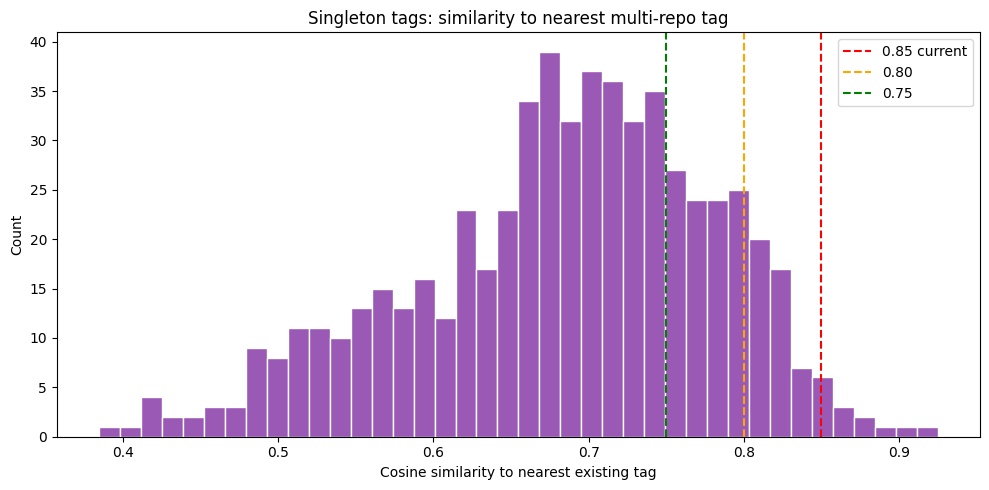

Saved singleton_proximity.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_sim, bins=40, color='#9b59b6', edgecolor='white')
for thresh, col, lbl in [(0.85,'red','0.85 current'), (0.80,'orange','0.80'), (0.75,'green','0.75')]:
    ax.axvline(thresh, color=col, linestyle='--', label=lbl)
ax.set_title('Singleton tags: similarity to nearest multi-repo tag')
ax.set_xlabel('Cosine similarity to nearest existing tag')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('singleton_proximity.png', dpi=120)
plt.show()
print('Saved singleton_proximity.png')

---
## Summary & Recommendations

| Issue | Finding | Recommendation |
|-------|---------|----------------|
| Language tags source | TBD | TBD |
| Dedup threshold | TBD | TBD |
| Singleton quality | TBD | TBD |